In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

import joblib

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (8, 5)

In [8]:
data_paths = [
    '../data/Mall_Customers.csv',
    'data/Mall_Customers.csv',
    'Mall_Customers.csv'
]

for path in data_paths:
    try:
        df = pd.read_csv(path)
        print('Loaded file:', path)
        break
    except FileNotFoundError:
        continue
else:
    raise FileNotFoundError('Mall_Customers.csv not found in expected locations.')

display(df.head())
print('Shape:', df.shape)
display(df.describe(include='all'))

Loaded file: ../data/Mall_Customers.csv


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


## 2) Select Features and Scale

In [9]:
feature_cols = ['Annual Income (k$)', 'Spending Score (1-100)']
X = df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Features used:', feature_cols)
print('Scaled shape:', X_scaled.shape)

Features used: ['Annual Income (k$)', 'Spending Score (1-100)']
Scaled shape: (200, 2)


## 3) Find Optimal K (Elbow + Silhouette)

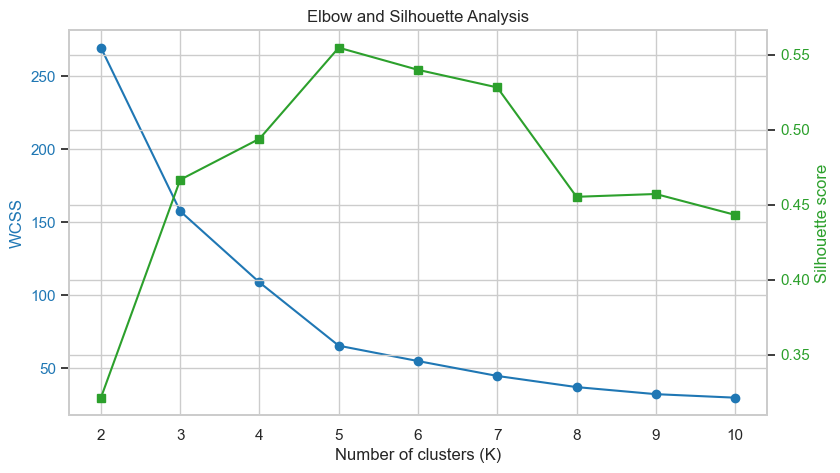

Chosen K: 5


In [10]:
k_values = list(range(2, 11))
wcss = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(k_values, wcss, marker='o', color='tab:blue')
ax1.set_xlabel('Number of clusters (K)')
ax1.set_ylabel('WCSS', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(k_values, sil_scores, marker='s', color='tab:green')
ax2.set_ylabel('Silhouette score', color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')

plt.title('Elbow and Silhouette Analysis')
plt.show()

optimal_k = k_values[int(np.argmax(sil_scores))]
print('Chosen K:', optimal_k)

## 4) Train K-Means and Visualize Clusters

,Annual Income (k$),Spending Score (1-100)
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


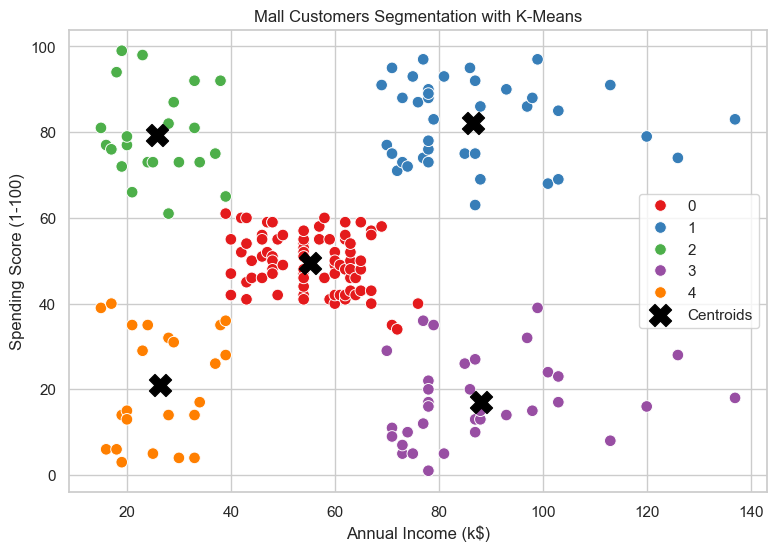

In [11]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids_original, columns=feature_cols)
display(centroids_df)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='cluster', palette='Set1', s=70)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1], marker='X', s=250, c='black', label='Centroids')
plt.title('Mall Customers Segmentation with K-Means')
plt.legend()
plt.show()

## 5) Evaluate and Save Artifacts

In [12]:
sil = silhouette_score(X_scaled, df['cluster'])
dbi = davies_bouldin_score(X_scaled, df['cluster'])

print(f'Silhouette Score: {sil:.4f}')
print(f'Davies-Bouldin Index: {dbi:.4f} (lower is better)')

cluster_profile = df.groupby('cluster')[feature_cols].mean().round(2)
display(cluster_profile)

label_by_rank = [
    'Careful Customers',
    'Value Seekers',
    'Premium Potential',
    'High Spenders',
    'Affluent Balanced',
    'Luxury Focused',
]

cluster_order = cluster_profile.sort_values(['Annual Income (k$)', 'Spending Score (1-100)']).index.tolist()
cluster_labels = {
    cluster_id: label_by_rank[min(i, len(label_by_rank) - 1)]
    for i, cluster_id in enumerate(cluster_order)
}

df['segment'] = df['cluster'].map(cluster_labels)
cluster_profile_labeled = cluster_profile.copy()
cluster_profile_labeled['Segment'] = cluster_profile_labeled.index.map(cluster_labels)
display(cluster_profile_labeled)

joblib.dump(kmeans, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(feature_cols, 'feature_columns.pkl')
joblib.dump(cluster_profile, 'cluster_profile.pkl')
joblib.dump(cluster_labels, 'cluster_labels.pkl')

print('Saved: model.pkl, scaler.pkl, feature_columns.pkl, cluster_profile.pkl, cluster_labels.pkl')

Silhouette Score: 0.5547
Davies-Bouldin Index: 0.5722 (lower is better)


,Annual Income (k$),Spending Score (1-100)
cluster,,
0,55.30,49.52
1,86.54,82.13
2,25.73,79.36
3,88.20,17.11
4,26.30,20.91


,Annual Income (k$),Spending Score (1-100),Segment
cluster,,,
0,55.30,49.52,Premium Potential
1,86.54,82.13,High Spenders
2,25.73,79.36,Careful Customers
3,88.20,17.11,Affluent Balanced
4,26.30,20.91,Value Seekers


Saved: model.pkl, scaler.pkl, feature_columns.pkl, cluster_profile.pkl, cluster_labels.pkl
